# Intro — Clustering in Action — Map Data Visualization with Python

Discovering Spatial Patterns with OSMnx, Scikit-learn, and Folium

#### Introduction
Previously, in our machine learning mini-series, we discussed K-means clustering and briefly mentioned its application to geographical data.

In this article, we put that theory into practice. We’ll use Python to apply K-means clustering directly to map data, using OpenStreetMap as our source, Scikit-learn for the algorithm, and Folium for visualization. This end-to-end project demonstrates how a fundamental machine learning method can turn a map into a story about urban patterns, density, and commercial life.

#### What We’ll Build
In this project, we’ll create interactive maps that visualize the spatial clusters of Points of Interest (POI, such as restaurants) for a given city using Python’s geospatial toolkits.

#### !pip install osmnx folium scikit-learn numpy geopandas or conda activate geo_env

### Section 1 — Understanding the Map Dataset
Before we can find patterns, we need the raw points on the map. Here, we use OSMnx to fetch restaurant data from OpenStreetMap.

#### 1.1 Get Map Dataset

In [1]:
# Final Demo Version
# @title Step 1 - Get Map Dataset
# Import libraries
import osmnx as ox
import folium
from sklearn.cluster import KMeans
import numpy as np

# Set the region, e.g., city name
place_name = "Tarifa, Spain"

# Download restaurant data for the specified region
tags = {'amenity': 'restaurant'}
gdf_restaurants = ox.features_from_place(place_name, tags=tags)

# View the data
print("First rows of downloaded data:")
print(gdf_restaurants.head())
print(f"\nTotal entries downloaded: {len(gdf_restaurants)}")

# Filter only Point geometry objects (remove polygons, etc.)
gdf_restaurants_points = gdf_restaurants[gdf_restaurants.geometry.type == 'Point'].copy()
print(f"Entries with Point geometry: {len(gdf_restaurants_points)}")

First rows of downloaded data:
                                     geometry air_conditioning     amenity  \
element id                                                                   
node    1232961904  POINT (-5.75592 36.18546)              yes  restaurant   
        1968170651  POINT (-5.68139 36.06617)              NaN  restaurant   
        1968199441  POINT (-5.68263 36.06969)              NaN  restaurant   
        1968252460  POINT (-5.68957 36.06933)              NaN  restaurant   
        2018752823  POINT (-5.61331 36.01911)              yes  restaurant   

                                           contact:facebook     contact:phone  \
element id                                                                      
node    1232961904  https://m.facebook.com/100063534284640/  +34 956 68 71 32   
        1968170651                                      NaN               NaN   
        1968199441                                      NaN               NaN   
        196825246

Purpose: Tells OSMnx what to download and from where.
* tags={‘amenity’: ‘restaurant’}: Defines the query to find all ‘restaurant’ tagged objects in OpenStreetMap.
* ox.features_from_place(): Fetches all matching features within the place_name boundary, returning a structured GeoDataFrame (gdf_restaurants).
* Result: gdf_restaurants is the raw dataset, a table of all restaurants with their locations and attributes.

### Section 2 — Discovering Patterns with Clustering
This section covers the core analytical step of clustering.

2.1 Discovering Patterns with Clustering
This step applies the K-means algorithm to find spatial groupings in the restaurant data.

* Transforming Geometry into Coordinates Extracts the latitude (y) and longitude (x) from each point’s geometry. 
* Creates a NumPy array, the standard data format for scikit-learn. Initializes the unsupervised learning model. random_state=0 ensures reproducible results.
* kmeans.fit_predict(): The core action. It finds cluster centers and assigns each restaurant’s coordinates to the nearest one, storing the result in a new ‘cluster’ column.

In [2]:
# Final Demo Version
# @title Step 2 - Discovering Patterns with Clustering

# Extract latitude and longitude coordinates
coordinates = gdf_restaurants_points.geometry.apply(lambda geom: (geom.y, geom.x)).tolist()

# Convert coordinates to NumPy array for machine learning
coords_array = np.array(coordinates)
print(f"Shape of coordinate array: {coords_array.shape}")

# Perform K-means clustering
n_clusters = 5  # Set number of clusters
kmeans = KMeans(n_clusters=n_clusters, n_init=10, random_state=0)
gdf_restaurants_points.loc[:, 'cluster'] = kmeans.fit_predict(coords_array)

print("Clustering complete. Cluster counts:")
print(gdf_restaurants_points['cluster'].value_counts().sort_index())

Shape of coordinate array: (93, 2)
Clustering complete. Cluster counts:
cluster
0    71
1     3
2     8
3     5
4     6
Name: count, dtype: int64


### Section 3 — Visualizing Insights on the Map
This section turns the clustered data into interactive maps for exploration.

#### 3.1 Map Creation and Visualization
This step builds the final interactive map from the clustered data.

In [3]:
# Final Demo Version
# @title Step 3  - Map Creation and Visualization

# Create base map, centered on the mean location of our points
mean_lat = gdf_restaurants_points.geometry.y.mean()
mean_lon = gdf_restaurants_points.geometry.x.mean()
m = folium.Map(location=[mean_lat, mean_lon], zoom_start=13)

# Add circle markers in different colors for each cluster
colors = ['red', 'blue', 'green', 'purple', 'orange']
for i in range(n_clusters):
    cluster_data = gdf_restaurants_points[gdf_restaurants_points['cluster'] == i]
    for idx, row in cluster_data.iterrows():
        folium.CircleMarker(
            location=(row.geometry.y, row.geometry.x),
            radius=5,
            color=colors[i],
            fill=True,
            fill_opacity=0.6,
            popup=row['name'] if 'name' in row else 'Restaurant'
        ).add_to(m)

# Save map as HTML file
output_file = 'tarifa_restaurants_map_with_clustering.html'
m.save(output_file)
print(f"Map saved as '{output_file}'")

# Display the map inline
print("\nDisplaying interactive map:")
m

Map saved as 'tarifa_restaurants_map_with_clustering.html'

Displaying interactive map:


### Section 4 — Different Cities, Same Method
We now combine the previous steps into a single, end-to-end script.

* https://wiki.openstreetmap.org/wiki/Key:amenity

#### 4.1 Leipzig, Germany
In the previous sections, we deconstructed the process for clarity. Now, we’ll execute it as a unified script. To analyze a different city, simply update the place_name variable.

In [4]:
# Final Demo Version - Portland, USA
# Import libraries
import osmnx as ox
import folium
from sklearn.cluster import KMeans
import numpy as np

# Set the region to a city in the US
place_name = "Leipzig, Germany"

# Download restaurant data for the specified region
tags = {'amenity': 'restaurant'}
gdf_restaurants = ox.features_from_place(place_name, tags=tags)

# View the data
print(gdf_restaurants.head())

# Filter only Point geometry objects
gdf_restaurants_points = gdf_restaurants[gdf_restaurants.geometry.type == 'Point'].copy()

# Extract latitude and longitude coordinates
coordinates = gdf_restaurants_points.geometry.apply(lambda geom: (geom.y, geom.x)).tolist()

# Convert coordinates to NumPy array
coords_array = np.array(coordinates)

# Perform K-means clustering
n_clusters = 5  # Set number of clusters
kmeans = KMeans(n_clusters=n_clusters, n_init=10, random_state=0)
gdf_restaurants_points.loc[:, 'cluster'] = kmeans.fit_predict(coords_array)

# Create base map
m = folium.Map(location=[gdf_restaurants_points.geometry.y.mean(), gdf_restaurants_points.geometry.x.mean()], zoom_start=13)

# Add circle markers in different colors for each cluster
colors = ['red', 'blue', 'green', 'purple', 'orange']
for i in range(n_clusters):
    cluster_data = gdf_restaurants_points[gdf_restaurants_points['cluster'] == i]
    for idx, row in cluster_data.iterrows():
        folium.CircleMarker(
            location=(row.geometry.y, row.geometry.x),
            radius=5,
            color=colors[i],
            fill=True,
            fill_opacity=0.6,
            popup=row['name'] if 'name' in row else 'Restaurant'
        ).add_to(m)

# Save map as HTML file
m.save('Leipzig_restaurants_map_with_clustering.html')

# Display map
m

                                    geometry addr:city addr:country  \
element id                                                            
node    30162037   POINT (12.27248 51.34466)   Leipzig           DE   
        50837889    POINT (12.3739 51.32366)       NaN          NaN   
        82686910   POINT (12.45523 51.39222)   Leipzig           DE   
        206121192  POINT (12.37383 51.33251)   Leipzig          NaN   
        206129565  POINT (12.31431 51.32695)   Leipzig          NaN   

                  addr:housenumber             addr:street     amenity  \
element id                                                               
node    30162037                11            Kastanienweg  restaurant   
        50837889                75  Karl-Liebknecht-Straße  restaurant   
        82686910                21    Plaußiger Dorfstraße  restaurant   
        206121192               17          Peterssteinweg  restaurant   
        206129565               28                Am Kanal

#### 4.2 - Surf schools

In [10]:
# Final Demo Version - Portland, USA
# Import libraries
import osmnx as ox
import folium
from sklearn.cluster import KMeans
import numpy as np

# Set the region to a city in the US
place_name = "Fuerteventura, Spain"

# Download restaurant data for the specified region
# 1. Use more common OSM tags for sports/surf centers
tags = {
    'leisure': 'sports_centre',
    'shop': 'sports'
}

gdf_surf = ox.features_from_place(place_name, tags=tags)

# 2. Filter for 'surf' in the name or sport column to be precise
if not gdf_surf.empty:
    # This looks for "surf" (case insensitive) in any column that might mention the sport
    mask = gdf_surf.astype(str).apply(lambda x: x.str.contains('surf', case=False)).any(axis=1)
    gdf_surf = gdf_surf[mask]


# View the data
print(gdf_surf.head())

# Filter only Point geometry objects
gdf_surf_points = gdf_surf[gdf_surf.geometry.type == 'Point'].copy()

# Extract latitude and longitude coordinates
coordinates = gdf_surf_points.geometry.apply(lambda geom: (geom.y, geom.x)).tolist()

# Convert coordinates to NumPy array
coords_array = np.array(coordinates)

# Perform K-means clustering
n_clusters = 5  # Set number of clusters
kmeans = KMeans(n_clusters=n_clusters, n_init=10, random_state=0)
gdf_surf_points.loc[:, 'cluster'] = kmeans.fit_predict(coords_array)

# Create base map
m = folium.Map(location=[gdf_surf_points.geometry.y.mean(), gdf_surf_points.geometry.x.mean()], zoom_start=13)

# Add circle markers in different colors for each cluster
colors = ['red', 'blue', 'green', 'purple', 'orange']
for i in range(n_clusters):
    # FIXED: Changed gdf_restaurants_points to gdf_surf_points
    cluster_data = gdf_surf_points[gdf_surf_points['cluster'] == i]
    
    for idx, row in cluster_data.iterrows():
        folium.CircleMarker(
            location=(row.geometry.y, row.geometry.x),
            radius=5,
            color=colors[i],
            fill=True,
            fill_opacity=0.6,
            popup=row['name'] if 'name' in row and not isinstance(row['name'], float) else 'Surf School'
        ).add_to(m)

# Save and Display
m.save('Corralejo_SurfSchools_map_with_clustering.html')
m  # This will render the map in your notebook

                                      geometry leisure                 name  \
element id                                                                    
node    2742910737  POINT (-13.86834 28.73715)     NaN         Element Surf   
        3781765774  POINT (-13.86877 28.73678)     NaN            Surf Life   
        3892140191  POINT (-14.00932 28.68238)     NaN   Riders Surf'n'Bike   
        3892140192  POINT (-14.00935 28.68253)     NaN           Shock-Wave   
        4796887921   POINT (-14.3436 28.04791)     NaN  Surf- & Segelschule   

                      shop       operator            sport addr:city  \
element id                                                             
node    2742910737  sports            NaN              NaN       NaN   
        3781765774  sports            NaN              NaN       NaN   
        3892140191  sports            NaN              NaN       NaN   
        3892140192  sports            NaN          surfing       NaN   
        479688

#### 4.3 World Map
We can plot these cities on a world map to provide geographic context.

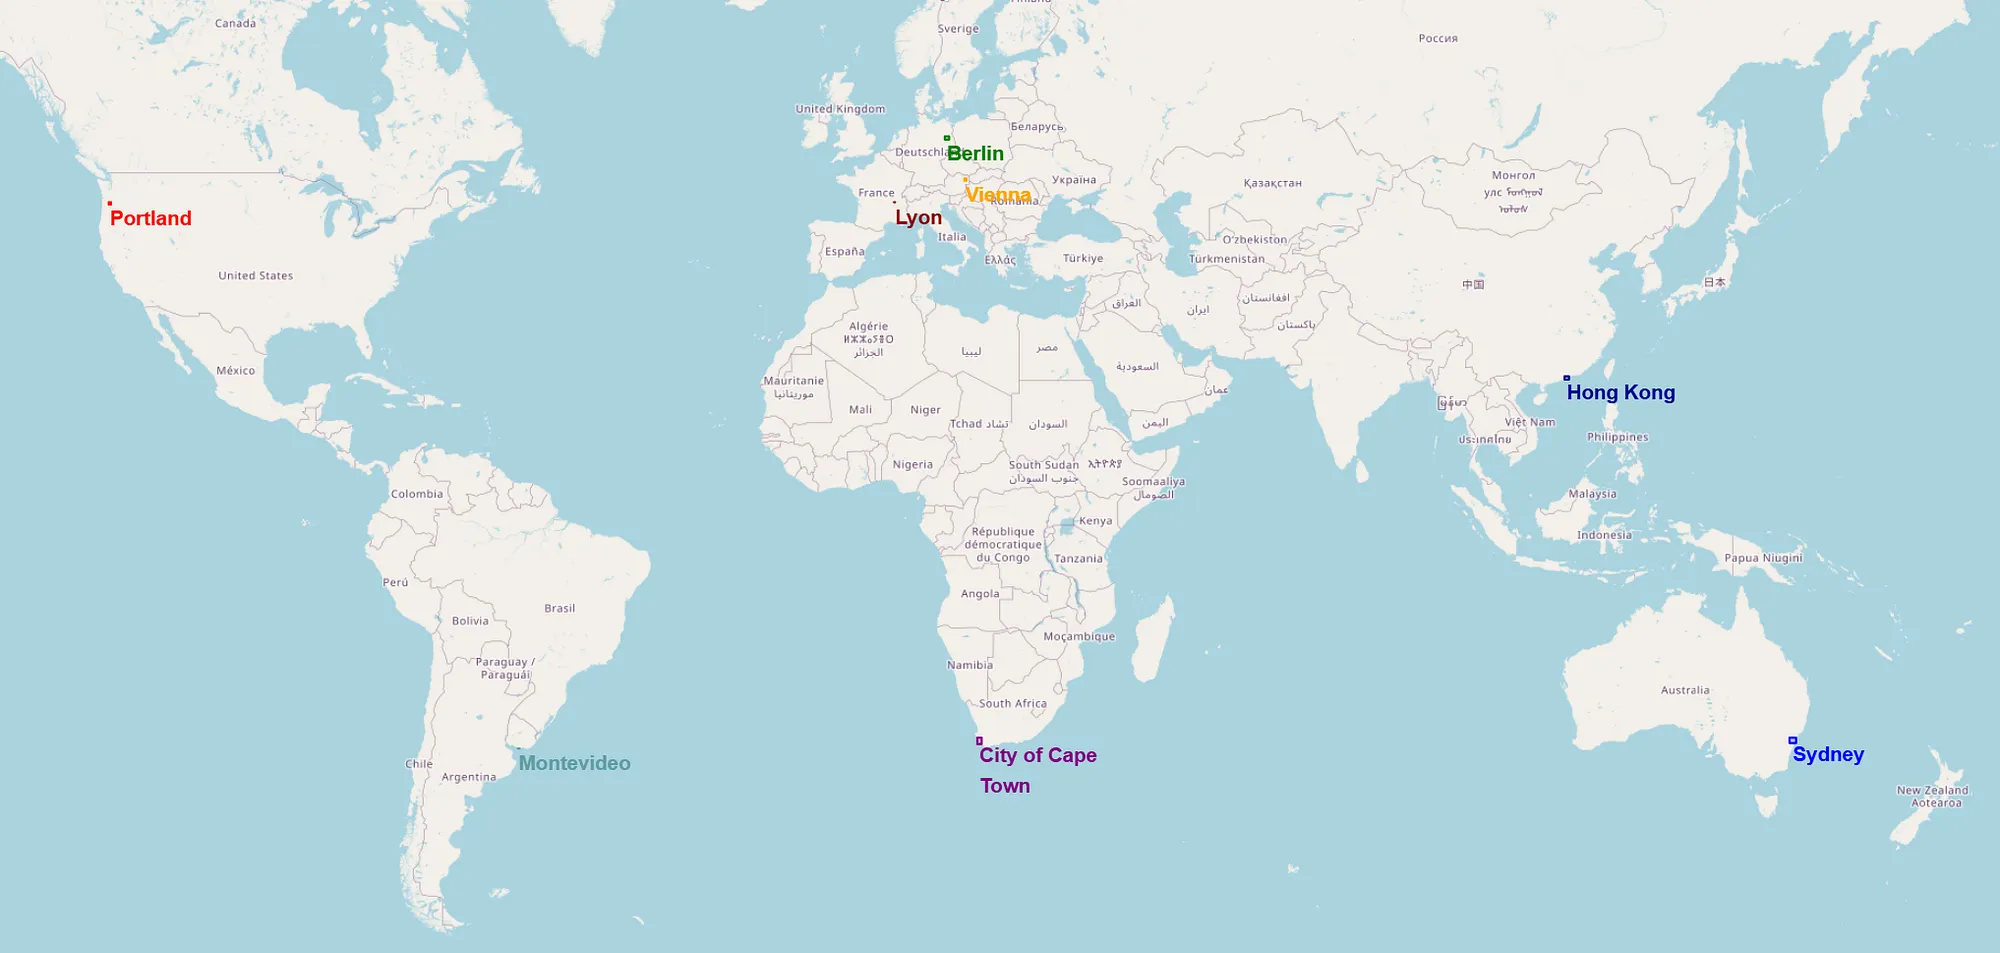

In [13]:
# Final Demo Version
import folium
import osmnx as ox
import geopandas as gpd
from shapely.geometry import box

# 1. Define the list of place name queries to resolve
place_queries = [
    "San Francisco, California, USA",
    "Osaka, Japan",
    "Leipzig, Germany",
    "City of Cape Town, Western Cape, South Africa",
    "Municipality of Athens, Greece",
    "Biarritz, France",
    "Bangkok, Thailand",
    "Mexico City, Mexico"
]

# 2. Create a base world map
world_map = folium.Map(location=[20, 0], zoom_start=2, tiles='OpenStreetMap')
colors = ['red', 'blue', 'green', 'purple', 'orange', 'darkred', 'darkblue', 'cadetblue']

# 3. Loop through each query, resolve it, and add to the map
for i, query in enumerate(place_queries):
    try:
        # Step A: Use OSMnx to get the city's boundary (GeoDataFrame)
        gdf_place = ox.geocode_to_gdf(query)
        
        # Step B: Get the bounding box and name from the result
        # The bounds are in order: (minx, miny, maxx, maxy)
        minx, miny, maxx, maxy = gdf_place.iloc[0].geometry.bounds
        resolved_name = gdf_place.iloc[0]['display_name']
        simple_name = query.split(",")[0] # Use first part of query for the label (e.g., "Portland")
        
        # Step C: Create a rectangle polygon from the bounds
        bbox_polygon = box(minx, miny, maxx, maxy)
        bbox_gdf = gpd.GeoDataFrame({'Name': [simple_name]}, geometry=[bbox_polygon], crs="EPSG:4326")
        geo_json_data = bbox_gdf.to_json()
        
        # Step D: Add the boundary to the map
        folium.GeoJson(
            geo_json_data,
            style_function=lambda feature, color=colors[i]: {
                'fillColor': color,
                'color': color,
                'weight': 2,
                'fillOpacity': 0.2
            },
            name=f"{simple_name} Boundary",
            tooltip=f"{resolved_name}" # Show full name on hover
        ).add_to(world_map)
        
        # Step E: Calculate center and add the visible label
        center_lat = (miny + maxy) / 2
        center_lon = (minx + maxx) / 2
        
        label = folium.DivIcon(
            icon_size=(150, 36),
            icon_anchor=(0, 0),
            html=f'<div style="font-size: 14pt; font-weight: bold; color: {colors[i]};">{simple_name}</div>'
        )
        
        folium.Marker(
            location=[center_lat, center_lon],
            icon=label,
            tooltip=resolved_name
        ).add_to(world_map)
        
        print(f"✓ Added: {simple_name} ({resolved_name})")
        
    except Exception as e:
        # If a city fails to geocode (e.g., wrong query format), print error and skip it
        print(f"✗ Failed to resolve '{query}': {e}")
        continue

# 4. Add layer control and display the map
folium.LayerControl().add_to(world_map)
print("\nMap creation complete. Displaying...")
world_map.save('world_map_with_clustering.html')
world_map

✓ Added: San Francisco (San Francisco, California, United States)
✓ Added: Osaka (Osaka, Osaka Prefecture, Japan)
✓ Added: Leipzig (Leipzig, Saxony, Germany)
✓ Added: City of Cape Town (City of Cape Town, Western Cape, South Africa)
✓ Added: Municipality of Athens (Municipality of Athens, Regional Unit of Central Athens, Attica, Greece)
✓ Added: Biarritz (Biarritz, Bayonne, Pyrénées-Atlantiques, Nouvelle-Aquitaine, Metropolitan France, 64200, France)
✓ Added: Bangkok (Bangkok, Thailand)
✓ Added: Mexico City (Mexico City, Mexico)

Map creation complete. Displaying...
